# Notebook 08: RL Environment Validation

**Purpose:** Verify and validate the Gymnasium reinforcement learning environment `EcoTwinEnv` with a random action agent before launching PPO training.


In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(str(Path("..").resolve()))
from backend.rl.environment import EcoTwinEnv


2026-08-21 12:02:00,784 [INFO] EcoTwin: Logging initialized successfully


2026-08-21 12:02:00,786 [INFO] EcoTwin: SUMO_HOME verified: C:\Program Files (x86)\Eclipse\Sumo\


### Initialize and Step through Gymnasium Environment

In [2]:
env = EcoTwinEnv(config={
    "scenario": "training",
    "gui": False,
    "step_length": 1.0,
    "max_steps": 100
})

obs, info = env.reset(seed=42)
print("Initial Reset Observation Shape:", obs.shape)
print("Initial Reset Observation Values:", obs)

rewards = []
co2_list = []
wait_list = []

for step in range(100):
    # Sample random action
    action = env.action_space.sample()
    
    # Step environment
    obs, reward, terminated, truncated, info = env.step(action)
    
    # Check for invalid values
    assert not np.isnan(obs).any(), f"NaN in obs at step {step}"
    assert not np.isinf(obs).any(), f"Inf in obs at step {step}"
    assert not np.isnan(reward), f"NaN in reward at step {step}"
    
    rewards.append(reward)
    co2_list.append(obs[0] + obs[1] + obs[2] + obs[3]) # Proxied queue co2 indicators
    wait_list.append(np.mean(obs[4:]))
    
    if terminated or truncated:
        break

env.close()
print("Random agent steps completed successfully. No NaNs or Inf values detected.")


Initial Reset Observation Shape: (8,)
Initial Reset Observation Values: [0. 0. 0. 0. 0. 0. 0. 0.]


SUMO simulation closed.
Random agent steps completed successfully. No NaNs or Inf values detected.


### Diagnostics Plots

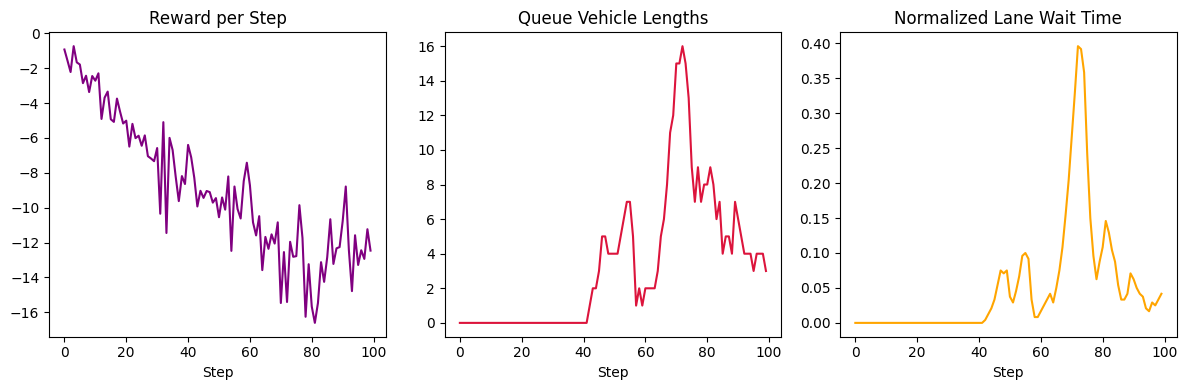

In [3]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(rewards, color="purple")
plt.title("Reward per Step")
plt.xlabel("Step")

plt.subplot(1, 3, 2)
plt.plot(co2_list, color="crimson")
plt.title("Queue Vehicle Lengths")
plt.xlabel("Step")

plt.subplot(1, 3, 3)
plt.plot(wait_list, color="orange")
plt.title("Normalized Lane Wait Time")
plt.xlabel("Step")

plt.tight_layout()
plt.savefig("../reports/figures/random_agent_diagnostics.png", dpi=300)
plt.show()
